In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings('ignore')

## Plotting
This notebook generates the plots in Dai et al 2025 using simulations generated in another notebook.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.interpolate import interp1d
import pandas as pd
import sncosmo
from scipy import stats
from scipy.special import expit
from nested_pandas import read_parquet
from joblib import Parallel, delayed
from scipy.stats import chi2
import cloudpickle as pickle
from astropy.cosmology import FlatLambdaCDM
from ndtest import ks2d2s
from astropy.time import Time
from sklearn.mixture import GaussianMixture
from matplotlib.patches import Ellipse
from matplotlib.ticker import LogLocator

from lightcurvelynx.astro_utils.mag_flux import mag2flux,flux2mag
from lightcurvelynx.utils.plotting import plot_lightcurves
from lightcurvelynx.graph_state import GraphState
from lightcurvelynx.simulate import compute_single_noise_free_lightcurve

from lightcurvelynx import _LIGHTCURVELYNX_BASE_DATA_DIR

from utils.plotting_utils import (plot_snr_distr, 
                                plot_logflux_vs_logfluxerr,
                                plot_logflux_vs_logfluxerr_corner,
                                plot_logmaxflux_vs_logmaxfluxerr,
                                plot_logmaxflux_vs_logmaxfluxerr_corner,
                                convert_flux_to_mag,
                                plot_mag_vs_magerr,
                                convert_flux_to_njy,
                                plot_flux_vs_fluxerr,
                                )

from ztf_snia_sim_params import SIM_PARAMS

from utils.analysis_utils import get_sn_host_sep

import matplotlib
from cycler import cycler

In [4]:
matplotlib.style.use('seaborn-v0_8-paper')

In [5]:
plt.rcParams.update({
    "figure.figsize": (6, 4),
    "text.usetex": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.frameon": False,
})

In [6]:
H0 = SIM_PARAMS["H0"]
OMEGA_M = SIM_PARAMS["Omega_m"]
ALPHA = SIM_PARAMS["alpha"]
BETA = SIM_PARAMS["beta"]
MAGABS = SIM_PARAMS["mag_abs"]
SIGMA_MAGABS = SIM_PARAMS["sigma_mag_abs"]

#### Read in ZTF SN DR2 data

In [7]:
globalhostdata = pd.read_csv('ztfsniadr2/tables/globalhost_data.csv')
localhostdata = pd.read_csv('ztfsniadr2/tables/localhost_data.csv')
sndata = pd.read_csv('ztfsniadr2/tables/snia_data.csv')
data = pd.merge(sndata,globalhostdata,on='ztfname')

In [8]:
print("Data Redshift Range:",sndata.redshift.min(), sndata.redshift.max())

Data Redshift Range: 0.00245848 0.28779283


In [9]:
print("Data Sample Size:",len(sndata))

Data Sample Size: 3628


In [10]:
lcdata = read_parquet('data/ztfsniadr2.parquet')

In [11]:
t = Time([lcdata['lc.mjd'].min(),lcdata['lc.mjd'].max()], format='mjd', scale='utc')
print("Light Curve MJD Range:")
print(t.to_datetime())

Light Curve MJD Range:
[datetime.datetime(2017, 11, 4, 13, 3, 38, 16000)
 datetime.datetime(2024, 4, 19, 8, 40, 14, 592000)]


In [12]:
t = Time([sndata['t0'].min(),sndata['t0'].max()], format='mjd', scale='utc')
print("Light Curve PeakMJD Range:")
print(t.to_datetime())

Light Curve PeakMJD Range:
[datetime.datetime(2018, 1, 12, 18, 41, 28, 148325)
 datetime.datetime(2021, 1, 11, 17, 57, 29, 61945)]


#### Read in simulations

In [13]:
lightcurves = read_parquet('results/lightcurves.parquet')

In [14]:
lightcurves = lightcurves.rename(columns={"lightcurve":"lc"})

In [15]:
t = Time([lightcurves['lc.mjd'].min(),lightcurves['lc.mjd'].max()], format='mjd', scale='utc')
print("Sim Light Curve MJD Range:")
print(t.to_datetime())

Sim Light Curve MJD Range:
[datetime.datetime(2018, 6, 19, 4, 7, 30)
 datetime.datetime(2021, 2, 28, 13, 24, 22, 500000)]


In [16]:
lightcurves.head()

id          ra        dec  nobs            t0         z  \
0   0  127.978813  23.512839   741  58461.402165  0.074747   
1   1  304.858738  69.527167   854  58994.257449  0.191377   
2   2  193.177977 -16.186343   156  58348.346806  0.146783   
3   3  231.913841 -18.901383   152  58464.224007  0.114567   
4   4  355.032567 -33.498347    51  58786.375942  0.173284   

                                              params  source_x0  source_x1  \
0  {'DistModFromRedshift:_distmod_from_redshift_1...   0.000318  -0.164099   
1  {'DistModFromRedshift:_distmod_from_redshift_1...   0.000004  -3.560757   
2  {'DistModFromRedshift:_distmod_from_redshift_1...   0.000017  -2.095448   
3  {'DistModFromRedshift:_distmod_from_redshift_1...    0.00024   0.335408   
4  {'DistModFromRedshift:_distmod_from_redshift_1...   0.000058  -2.172132   

   source_c  host_hostmass   source_ra  source_dec     host_ra   host_dec  \
0  0.338181       9.323363  127.978813   23.512839  127.978911  23.512796   
1  0.866296       10.77604  304.858738   69.527167  304.859105   69.52714   
2  0.742912       9.723345  193.177977  -16.186343   193.17845 -16.186387   
3  0.066992      10.234649  231.913841  -18.901383   231.91417 -18.900816   
4  0.119945       10.50861  355.032567  -33.498347  355.032544 -33.498356   

                                                  lc pass_spec_selection  \
0  [{mjd: 58369.523438, filter: 'r', flux: 18247....                True   
1  [{mjd: 58290.386719, filter: 'r', flux: -103.3...               False   
2  [{mjd: 58289.175781, filter: 'g', flux: -407.1...               False   
3  [{mjd: 58289.230469, filter: 'r', flux: -6890....               False   
4  [{mjd: 59106.292969, filter: 'g', flux: 8418.9...               False   

  pass_quality_cuts  __index_level_0__  
0              True                  0  
1             False                  1  
2             False                  2  
3             False                  3  
4             False                  4

In [56]:
lightcurves['lc.mjd'].count()

np.int64(75365656)

In [17]:
print("All sample simulated: nsn=", len(lightcurves))
# drop saturation
lightcurves_after_drop_sat = lightcurves.query("lc.is_saturated==False").dropna()
print("After dropping saturation: nsn=", len(lightcurves_after_drop_sat))
lightcurves_after_detection = lightcurves_after_drop_sat.query("lc.detection_flag == True").dropna()
print("After applying detection: nsn=", len(lightcurves_after_detection))
lightcurves_after_spec_selection = lightcurves.loc[lightcurves['pass_spec_selection']]
print("After spectroscopic selection: nsn=", len(lightcurves_after_spec_selection))
lightcurves_after_quality_cut = lightcurves.loc[lightcurves['pass_quality_cuts']]
print("After quality cuts: nsn=", len(lightcurves_after_quality_cut))

All sample simulated: nsn= 84687
After dropping saturation: nsn= 84687
After applying detection: nsn= 43303
After spectroscopic selection: nsn= 4313
After quality cuts: nsn= 3346


In [18]:
saltpars = pd.read_csv('results/salt3fit_results.csv')
len(saltpars)

3346

In [19]:
saltpars.columns

Index(['id', 'success', 'ncall', 'chisq', 'ndof', 'z', 'z_err', 't0', 't0_err',
       'x0', 'x0_err', 'x1', 'x1_err', 'c', 'c_err', 'mwebv', 'mwebv_err',
       'z_z_cov', 'z_t0_cov', 'z_x0_cov', 'z_x1_cov', 'z_c_cov', 'z_mwebv_cov',
       't0_z_cov', 't0_t0_cov', 't0_x0_cov', 't0_x1_cov', 't0_c_cov',
       't0_mwebv_cov', 'x0_z_cov', 'x0_t0_cov', 'x0_x0_cov', 'x0_x1_cov',
       'x0_c_cov', 'x0_mwebv_cov', 'x1_z_cov', 'x1_t0_cov', 'x1_x0_cov',
       'x1_x1_cov', 'x1_c_cov', 'x1_mwebv_cov', 'c_z_cov', 'c_t0_cov',
       'c_x0_cov', 'c_x1_cov', 'c_c_cov', 'c_mwebv_cov', 'mwebv_z_cov',
       'mwebv_t0_cov', 'mwebv_x0_cov', 'mwebv_x1_cov', 'mwebv_c_cov',
       'mwebv_mwebv_cov', 'fit_error'],
      dtype='object')

In [20]:
## make cuts based on salt parameters
saltpar_cuts = (saltpars.x1 > -3) & (saltpars.x1 < 3)
print("x1 > -3 & x1 < 3: ",np.sum(saltpar_cuts))
saltpar_cuts &= (saltpars.c > -0.2) & (saltpars.c < 0.8)
print("c > -0.2 & c < 0.8: ",np.sum(saltpar_cuts))
saltpar_cuts &= saltpars.t0_err < 1
print("sigma_t0 < 1: ",np.sum(saltpar_cuts))
saltpar_cuts &= saltpars.x1_err < 1
print("sigma_x1 < 1: ",np.sum(saltpar_cuts))
saltpar_cuts &= saltpars.c_err < 0.1
print("sigma_c < 0.1: ",np.sum(saltpar_cuts))

reduced = saltpars.chisq / saltpars.ndof
p_value = 1 - chi2.cdf(saltpars.chisq, df=saltpars.ndof)

saltpar_cuts &= p_value > 1e-7
print("fitprob > 1e-7: ",np.sum(saltpar_cuts))


x1 > -3 & x1 < 3:  3224
c > -0.2 & c < 0.8:  3159
sigma_t0 < 1:  3062
sigma_x1 < 1:  3031
sigma_c < 0.1:  3010
fitprob > 1e-7:  2992


1.1888092613009922


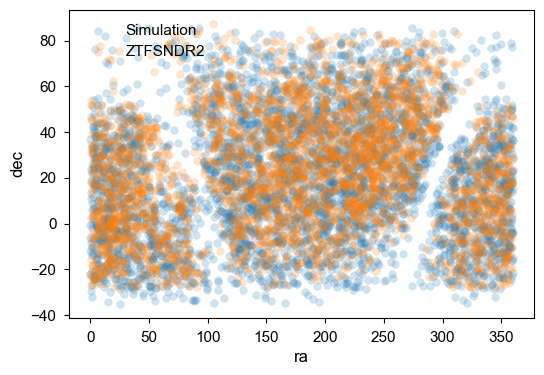

In [21]:
# plt.scatter(lightcurves['ra'],lightcurves['dec'],alpha=0.02)
# plt.scatter(lightcurves_after_detection['ra'],lightcurves_after_detection['dec'],alpha=0.1)
plt.scatter(lightcurves_after_spec_selection['ra'],lightcurves_after_spec_selection['dec'],alpha=0.2,label='Simulation')
plt.scatter(sndata['ra'],sndata['dec'],alpha=0.2,label='ZTFSNDR2')
plt.xlabel('ra')
plt.ylabel('dec')
plt.legend()
print(len(lightcurves_after_spec_selection)/len(sndata))

<Axes: >

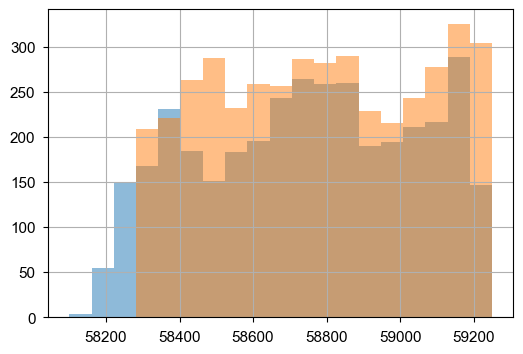

In [22]:
bins = np.linspace(58100, 59250,20)
sndata['t0'].hist(alpha=0.5,bins=bins,density=False)
lightcurves_after_spec_selection['t0'].hist(alpha=0.5,bins=bins,density=False)

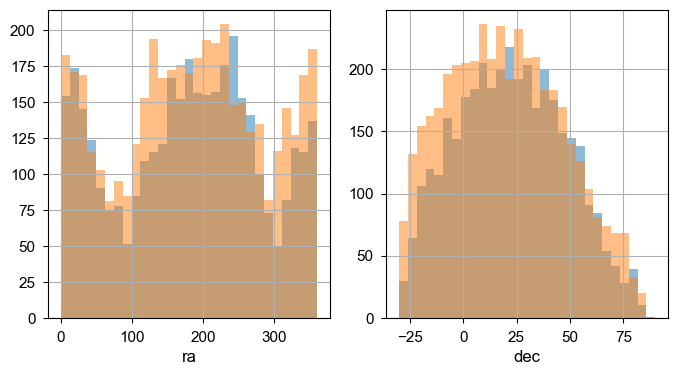

In [23]:
fig = plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
bins = np.linspace(0,360,30)
sndata['ra'].hist(alpha=0.5,bins=bins,density=False)
lightcurves_after_spec_selection['ra'].hist(alpha=0.5,bins=bins,density=False)
plt.xlabel('ra')
plt.subplot(1,2,2)
bins = np.linspace(-30,90,30)
sndata['dec'].hist(alpha=0.5,bins=bins,density=False)
lightcurves_after_spec_selection['dec'].hist(alpha=0.5,bins=bins,density=False)
plt.xlabel('dec')
plt.show()

### Fig. 2

In [24]:
sim_all_x1 = lightcurves['source_x1'].dropna()
sim_all_c = lightcurves['source_c'].dropna()

In [25]:
lc_to_plot = lightcurves_after_quality_cut
sim_x1 = lc_to_plot['source_x1'].dropna()
sim_c = lc_to_plot['source_c'].dropna()

In [26]:
def expo(x, a, b, c):
    x = np.asarray(x)
    y = a * np.exp(b * x) + c
    return y

In [27]:
fx1_parr = np.loadtxt('data/ztf_selection_func_x1.txt')
fc_parr = np.loadtxt('data/ztf_selection_func_c.txt')
fx1_func = lambda x1: expo(x1, *fx1_parr)
fc_func = lambda c: expo(c, *fc_parr)

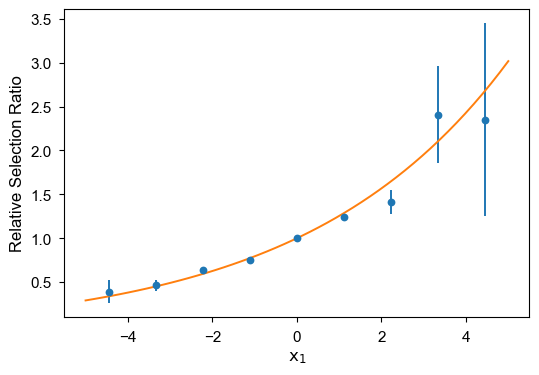

In [28]:
bins = np.linspace(-5,5,10)
x1before,bin_edges,_ = stats.binned_statistic(sim_all_x1,np.ones(len(lightcurves)), statistic='sum', bins=bins)
x1after,bin_edges,_ =  stats.binned_statistic(sim_x1, np.ones(len(lc_to_plot)), statistic='sum', bins=bins)
norm = 1./interp1d((bin_edges[:-1] + bin_edges[1:])/2.,x1after/x1before)(0)
err = np.sqrt(x1after**2/x1before**3 + x1after/x1before**2)
plt.errorbar((bin_edges[:-1] + bin_edges[1:])/2.,x1after/x1before*norm,yerr = err*norm, fmt='o')
xplot = np.linspace(-5,5,50)
plt.plot(xplot,fx1_func(xplot)/fx1_func(0))
plt.xlabel(r'$\mathrm{x_1}$')
plt.ylabel('Relative Selection Ratio')
plt.savefig('paper_figs/x1_selection.png', dpi=300, bbox_inches='tight')

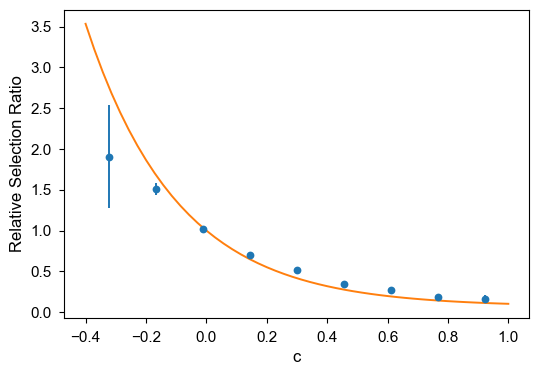

In [29]:
bins = np.linspace(-0.4,1,10)
cbefore,bin_edges,_ = stats.binned_statistic(sim_all_c,np.ones(len(lightcurves)), statistic='sum', bins=bins)
cafter,bin_edges,_ =  stats.binned_statistic(sim_c, np.ones(len(lc_to_plot)), statistic='sum', bins=bins)
norm = 1./interp1d((bin_edges[:-1] + bin_edges[1:])/2.,cafter/cbefore)(0)
err = np.sqrt(cafter**2/cbefore**3 + cafter/cbefore**2)
plt.errorbar((bin_edges[:-1] + bin_edges[1:])/2.,cafter/cbefore*norm,yerr = err*norm, fmt='o')
xplot = np.linspace(-0.4,1,50)
plt.plot(xplot,fc_func(xplot)/fc_func(0))
plt.xlabel('c')
plt.ylabel('Relative Selection Ratio')
plt.savefig('paper_figs/c_selection.png', dpi=300, bbox_inches='tight')

### Checking light curve fitting results

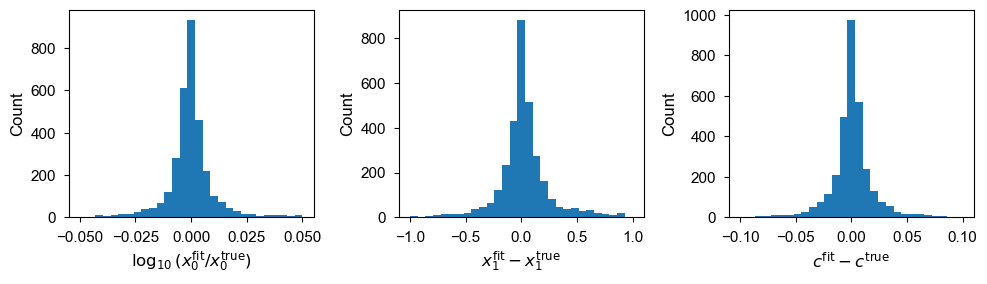

In [76]:
merged_saltpars = lightcurves_after_quality_cut.merge(saltpars,on='id')
fig = plt.figure(figsize=(10, 3))

ax = fig.add_subplot(1, 3, 1)
ax.hist(np.log10(merged.x0 / merged.source_x0), bins=np.linspace(-0.05, 0.05, 30))
ax.set_xlabel(r"$\log_{10}(x_0^{\rm fit} / x_0^{\rm true})$")
ax.set_ylabel("Count")

ax = fig.add_subplot(1, 3, 2)
ax.hist((merged["x1"] - merged["source_x1"]), bins=np.linspace(-1, 1, 30))
ax.set_xlabel(r"$x_1^{\rm fit} - x_1^{\rm true}$")
ax.set_ylabel("Count")

ax = fig.add_subplot(1, 3, 3)
ax.hist((merged["c"] - merged["source_c"]), bins=np.linspace(-0.1, 0.1, 30))
ax.set_xlabel(r"$c^{\rm fit} - c^{\rm true}$")
ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

### Define utils for fitting a Gaussian Mixture model

In [30]:
def fit_gmm_1d(data, k=2):
    X = np.asarray(data).reshape(-1, 1)
    gmm = GaussianMixture(
        n_components=k,
        n_init=10,
        reg_covar=1e-4,
        random_state=0
    ).fit(X)
    return gmm
def get_gmm_pars(gmm):
    weights = gmm.weights_
    means = gmm.means_.flatten()
    sigmas = np.sqrt(gmm.covariances_.flatten())
    sort_idx = np.argsort(means)
    return weights[sort_idx],means[sort_idx],sigmas[sort_idx]
def plot_gmm(x, gmm, ax=None, **kwargs):
    if ax is None:
        ax = plt.gca()

    weights, means, sigmas = get_gmm_pars(gmm)

    pdf = np.zeros_like(x, dtype=float)
    for w, mu, sig in zip(weights, means, sigmas):
        pdf += w * stats.norm.pdf(x, mu, sig)

    line, = ax.plot(x, pdf, **kwargs)
    return line

In [31]:
def fit_gmm_2d(x,y,k=2):
    X = np.column_stack([x, y])
    
    gmm = GaussianMixture(
        n_components=2,
        covariance_type="full",
        n_init=10,
        reg_covar=1e-6,
        random_state=0
    )
    gmm.fit(X)
    return gmm
def get_gmm_pars_2d(gmm):
    weights = gmm.weights_
    means = gmm.means_
    covs = gmm.covariances_
    return weights, means, covs
def plot_gmm_2d(X, Y, weights, means, covs, **kwargs):
    # grid
    xx, yy = np.meshgrid(
        np.linspace(X.min(), X.max(), 200),
        np.linspace(Y.min(), Y.max(), 200)
    )
    pos = np.dstack((xx, yy))
    
    pdf = np.zeros(xx.shape)
    for w, mu, cov in zip(weights, means, covs):
        pdf += w * stats.multivariate_normal(mu, cov).pdf(pos)
    
    plt.contour(xx, yy, pdf, **kwargs)

In [32]:
def bootstrap_gmm_errs_1d(data,k=2,n_boot=200):
    means_arr = []
    sigmas_arr  = []
    
    N = len(data)
    
    for _ in range(n_boot):
        idx = np.random.choice(N, N, replace=True)
        gmm = fit_gmm_1d(data.iloc[idx], k=k)
        weights,means,sigmas = get_gmm_pars(gmm)
        means_arr.append(means)
        sigmas_arr.append(sigmas)
    
    means_arr = np.array(means_arr)
    sigmas_arr  = np.array(sigmas_arr)

    mean_err = means_arr.std(axis=0)
    sigmas_err = sigmas_arr.std(axis=0)
    return mean_err,sigmas_err

### Fig. 4

KstestResult(statistic=np.float64(0.041370840821774856), pvalue=np.float64(0.008917644429486928), statistic_location=np.float64(0.08690352), statistic_sign=np.int8(-1))
Anderson_ksampResult(statistic=np.float64(2.5015134778061285), critical_values=array([0.325, 1.226, 1.961, 2.718, 3.752, 4.592, 6.546]), pvalue=0.03062352499584269)
KLD= 0.021080870498449714
$\Delta \xi = -0.0001 \pm 0.0015$
$\Delta \omega = 0.0007 \pm 0.0016$
$\Delta \kappa = 0.11 \pm 0.25$


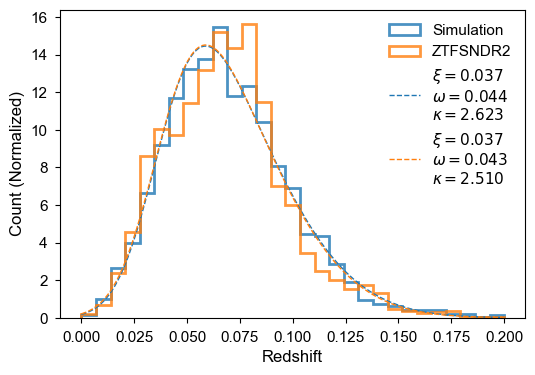

In [33]:
bmin, bmax = 0, 0.2
bins = np.linspace(bmin, bmax, 30)
lc_to_plot = lightcurves_after_quality_cut
z_data = data.loc[data.lccoverage_flag == 1].redshift

fig, ax = plt.subplots()  # <-- IMPORTANT

ax.hist(lc_to_plot['z'], bins=bins, alpha=0.8, density=True,
        histtype='step', label='Simulation', color='C0', lw=2)
ax.hist(z_data, bins=bins, alpha=0.8, density=True,
        histtype='step', label='ZTFSNDR2', color='C1', lw=2)

ks = stats.ks_2samp(lc_to_plot['z'], z_data)
print(ks)
ad = stats.anderson_ksamp([lc_to_plot['z'], z_data])
print(ad)

psim, _ = np.histogram(lc_to_plot['z'], bins=bins, density=True)
pdata, _ = np.histogram(z_data, bins=bins, density=True)
psim = np.clip(psim, 1.e-8, None)
pdata = np.clip(pdata, 1.e-8, None)
print("KLD=", stats.entropy(pdata, psim))

# ---- skewnorm fits (sim) ----
a_s, loc_s, scale_s = stats.skewnorm.fit(lc_to_plot['z'])
pars = np.array([stats.skewnorm.fit(lc_to_plot['z'].sample(frac=1, replace=True))
                 for _ in range(200)])
a_s_err, loc_s_err, scale_s_err = pars.std(axis=0)

x = np.linspace(bmin, bmax, 200)
pdf_s = stats.skewnorm.pdf(x, a_s, loc=loc_s, scale=scale_s)
ax.plot(x, pdf_s, color='C0', ls='--', lw=1,
        label=rf"$\xi={loc_s:.3f}$" "\n" rf"$\omega={scale_s:.3f}$" "\n" rf"$\kappa={a_s:.3f}$")

# ---- skewnorm fits (data) ----
a_d, loc_d, scale_d = stats.skewnorm.fit(z_data)
pars = np.array([stats.skewnorm.fit(z_data.sample(frac=1, replace=True))
                 for _ in range(200)])
a_d_err, loc_d_err, scale_d_err = pars.std(axis=0)

pdf_d = stats.skewnorm.pdf(x, a_d, loc=loc_d, scale=scale_d)
ax.plot(x, pdf_d, color='C1', ls='--', lw=1,
        label=rf"$\xi={loc_d:.3f}$" "\n" rf"$\omega={scale_d:.3f}$" "\n" rf"$\kappa={a_d:.3f}$")

# ---- append legend entries ----
extra_labels = [
    rf"$\Delta \xi = {loc_s - loc_d:.4f} \pm {np.sqrt(loc_s_err**2 + loc_d_err**2):.4f}$",
    rf"$\Delta \omega = {scale_s - scale_d:.4f} \pm {np.sqrt(scale_s_err**2 + scale_d_err**2):.4f}$",
    rf"$\Delta \kappa = {a_s - a_d:.2f} \pm {np.sqrt(a_s_err**2 + a_d_err**2):.2f}$",
]
extra_handles = [Line2D([], [], color="none", label=lab) for lab in extra_labels]

handles, labels = ax.get_legend_handles_labels()
# ax.legend(handles + extra_handles, labels + extra_labels, frameon=False)
ax.legend()

print(rf"$\Delta \xi = {loc_s - loc_d:.4f} \pm {np.sqrt(loc_s_err**2 + loc_d_err**2):.4f}$")
print(rf"$\Delta \omega = {scale_s - scale_d:.4f} \pm {np.sqrt(scale_s_err**2 + scale_d_err**2):.4f}$")
print(rf"$\Delta \kappa = {a_s - a_d:.2f} \pm {np.sqrt(a_s_err**2 + a_d_err**2):.2f}$")

ax.set_xlabel('Redshift')
ax.set_ylabel('Count (Normalized)')

plt.show()
fig.savefig('paper_figs/z_distr.png', dpi=300, bbox_inches='tight')

### Fig. 5

In [34]:
result_df = saltpars

KstestResult(statistic=np.float64(0.03886432195255725), pvalue=np.float64(0.027656999038259893), statistic_location=np.float64(0.8227372225527793), statistic_sign=np.int8(-1))
KLD= 0.0130229954185615
$\Delta\mu_1 = -0.00\,\pm\,0.08,\ 
\Delta\sigma_1 = 0.09\,\pm\,0.03$
$\Delta\mu_2 = 0.06\,\pm\,0.03,\ 
\Delta\sigma_2 = 0.06\,\pm\,0.02$


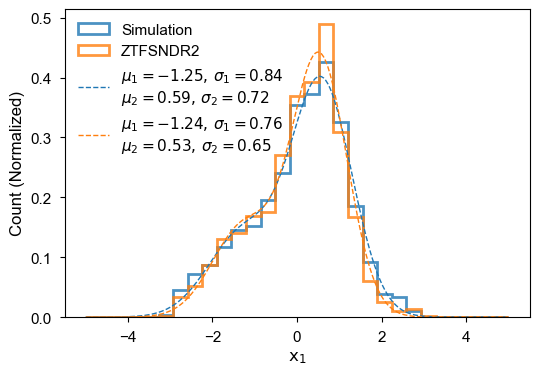

In [35]:
bmin, bmax = -5, 5
bins = np.linspace(bmin, bmax, 30)

idx = saltpar_cuts
data_idx = (data.fitquality_flag == True) & (data.lccoverage_flag == True) & ~data.x1.isna()

fig, ax = plt.subplots()

ax.hist(result_df[idx].x1, bins=bins, density=True, label='Simulation',
        histtype='step', lw=2, color='C0', alpha=0.8)
ax.hist(data[data_idx].x1, bins=bins, density=True, label='ZTFSNDR2',
        histtype='step', lw=2, color='C1', alpha=0.8)

ax.set_xlabel(r'$\mathrm{x_1}$')
ax.set_ylabel('Count (Normalized)')

# --- tests ---
ks = stats.ks_2samp(result_df[idx].x1, data[data_idx].x1)
print(ks)

psim, _ = np.histogram(result_df[idx].x1, bins=bins, density=True)
pdata, _ = np.histogram(data[data_idx].x1, bins=bins, density=True)
psim = np.clip(psim, 1.e-8, None)
pdata = np.clip(pdata, 1.e-8, None)
print("KLD=", stats.entropy(pdata, psim))

# --- GMM overlays ---
x = np.linspace(bmin, bmax, 200)

gmm_s = fit_gmm_1d(result_df[idx].x1)
weights_s, means_s, sigmas_s = get_gmm_pars(gmm_s)
plot_gmm(x, gmm_s, c='C0', ls='--', lw=1,
         label=rf"$\mu_1={means_s[0]:.2f},\,\sigma_1={sigmas_s[0]:.2f}$" "\n"
               rf"$\mu_2={means_s[1]:.2f},\,\sigma_2={sigmas_s[1]:.2f}$",
         ax=ax)  # <-- pass ax if your plot_gmm supports it

gmm_d = fit_gmm_1d(data[data_idx].x1)
weights_d, means_d, sigmas_d = get_gmm_pars(gmm_d)
plot_gmm(x, gmm_d, c='C1', ls='--', lw=1,
         label=rf"$\mu_1={means_d[0]:.2f},\,\sigma_1={sigmas_d[0]:.2f}$" "\n"
               rf"$\mu_2={means_d[1]:.2f},\,\sigma_2={sigmas_d[1]:.2f}$",
         ax=ax)

# --- bootstrap errs ---
mean_err_s, sigma_err_s = bootstrap_gmm_errs_1d(result_df[idx].x1, k=2)
mean_err_d, sigma_err_d = bootstrap_gmm_errs_1d(data[data_idx].x1, k=2)

dmu = means_s - means_d
dsigma = sigmas_s - sigmas_d
dmu_err = np.sqrt(mean_err_s**2 + mean_err_d**2)
dsigma_err = np.sqrt(sigma_err_s**2 + sigma_err_d**2)

def fmt_pm(val, err, prec=2):
    return rf"{val:.{prec}f}\,\pm\,{err:.{prec}f}"

extra_labels = []
for k in [0, 1]:
    extra_labels.append(
        rf"$\Delta\mu_{k+1} = {fmt_pm(dmu[k], dmu_err[k])},\ "
        rf"\Delta\sigma_{k+1} = {fmt_pm(dsigma[k], dsigma_err[k])}$"
    )
    print(rf"$\Delta\mu_{k+1} = {fmt_pm(dmu[k], dmu_err[k])},\ ")
    print(rf"\Delta\sigma_{k+1} = {fmt_pm(dsigma[k], dsigma_err[k])}$")

extra_handles = [Line2D([], [], color="none", label=lab) for lab in extra_labels]

# --- append to existing legend ---
handles, labels0 = ax.get_legend_handles_labels()
# ax.legend(handles + extra_handles, labels0 + extra_labels, frameon=False)
ax.legend()

plt.show()
fig.savefig("paper_figs/x1_distr.png", dpi=300, bbox_inches="tight")
plt.close(fig)


KstestResult(statistic=np.float64(0.07160976278623338), pvalue=np.float64(1.018306454968253e-06), statistic_location=np.float64(0.0787729017617224), statistic_sign=np.int8(-1))
KLD= 0.025262074261051214
$\Delta\mu_1 = 0.007\,\pm\,0.003,\ 
\Delta\sigma_1 = 0.013\,\pm\,0.002$
$\Delta\mu_2 = 0.071\,\pm\,0.026,\ 
\Delta\sigma_2 = 0.005\,\pm\,0.009$


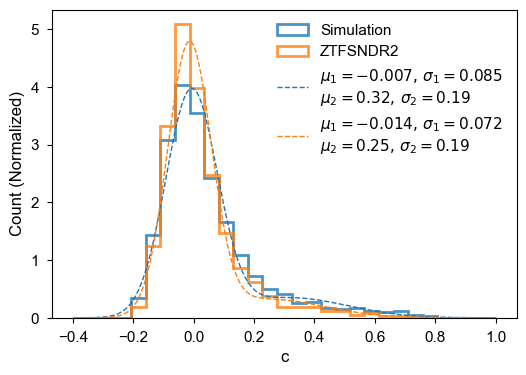

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats

bmin, bmax = -0.4, 1
bins = np.linspace(bmin, bmax, 30)

idx = saltpar_cuts
data_idx = (data.fitquality_flag == True) & (data.lccoverage_flag == True) & ~data.c.isna()

fig, ax = plt.subplots()

ax.hist(result_df[idx].c, bins=bins, density=True, label='Simulation',
        histtype='step', lw=2, color='C0', alpha=0.8)
ax.hist(data[data_idx].c, bins=bins, density=True, label='ZTFSNDR2',
        histtype='step', lw=2, color='C1', alpha=0.8)

ax.set_xlabel('c')
ax.set_ylabel('Count (Normalized)')

# --- tests ---
ks = stats.ks_2samp(result_df[idx].c, data[data_idx].c)
print(ks)

psim, _ = np.histogram(result_df[idx].c, bins=bins, density=True)
pdata, _ = np.histogram(data[data_idx].c, bins=bins, density=True)
psim = np.clip(psim, 1.e-8, None)
pdata = np.clip(pdata, 1.e-8, None)
print("KLD=", stats.entropy(pdata, psim))

# --- GMM overlays ---
x = np.linspace(bmin, bmax, 200)

gmm_s = fit_gmm_1d(result_df[idx].c)
weights_s, means_s, sigmas_s = get_gmm_pars(gmm_s)
plot_gmm(
    x, gmm_s, ax=ax, c='C0', ls='--', lw=1,
    label=rf"$\mu_1={means_s[0]:.3f},\,\sigma_1={sigmas_s[0]:.3f}$" "\n"
          rf"$\mu_2={means_s[1]:.2f},\,\sigma_2={sigmas_s[1]:.2f}$"
)

gmm_d = fit_gmm_1d(data[data_idx].c)
weights_d, means_d, sigmas_d = get_gmm_pars(gmm_d)
plot_gmm(
    x, gmm_d, ax=ax, c='C1', ls='--', lw=1,
    label=rf"$\mu_1={means_d[0]:.3f},\,\sigma_1={sigmas_d[0]:.3f}$" "\n"
          rf"$\mu_2={means_d[1]:.2f},\,\sigma_2={sigmas_d[1]:.2f}$"
)

# --- bootstrap errs ---
mean_err_s, sigma_err_s = bootstrap_gmm_errs_1d(result_df[idx].c, k=2)
mean_err_d, sigma_err_d = bootstrap_gmm_errs_1d(data[data_idx].c, k=2)

dmu = means_s - means_d
dsigma = sigmas_s - sigmas_d
dmu_err = np.sqrt(mean_err_s**2 + mean_err_d**2)
dsigma_err = np.sqrt(sigma_err_s**2 + sigma_err_d**2)

def fmt_pm(val, err, prec=3):
    return rf"{val:.{prec}f}\,\pm\,{err:.{prec}f}"

extra_labels = []
for k in [0, 1]:
    extra_labels.append(
        rf"$\Delta\mu_{k+1} = {fmt_pm(dmu[k], dmu_err[k])},\ "
        rf"\Delta\sigma_{k+1} = {fmt_pm(dsigma[k], dsigma_err[k])}$"
    )
    print(rf"$\Delta\mu_{k+1} = {fmt_pm(dmu[k], dmu_err[k])},\ ")
    print(rf"\Delta\sigma_{k+1} = {fmt_pm(dsigma[k], dsigma_err[k])}$")
    
extra_handles = [Line2D([], [], color="none", label=lab) for lab in extra_labels]

# --- append to legend (single final legend call) ---
handles, labels0 = ax.get_legend_handles_labels()
# ax.legend(handles + extra_handles, labels0 + extra_labels, frameon=False)
ax.legend()

plt.show()
fig.savefig('paper_figs/c_distr.png', dpi=300, bbox_inches='tight')
plt.close(fig)


### Fig. 6

In [37]:
lc_to_fit = lightcurves_after_quality_cut

In [38]:
merged = lc_to_fit.merge(result_df,on='id')

2992
2581
KS: 0.9999999999999868 0.07142857142857142
KLD= 0.09510217596520679
weights= [0.44062774 0.55937226]
means= [[10.36821971 -0.64138544]
 [ 9.35284486  0.56704294]]
covs= [[[ 0.16598816 -0.08745684]
  [-0.08745684  1.31724885]]

 [[ 0.80795363 -0.10582069]
  [-0.10582069  0.61488783]]]
weights= [0.43981198 0.56018802]
means= [[10.35085974 -0.66434935]
 [ 9.31592951  0.5339966 ]]
covs= [[[ 0.20025266 -0.12184184]
  [-0.12184184  1.10520301]]

 [[ 0.81274186 -0.07595279]
  [-0.07595279  0.4749042 ]]]


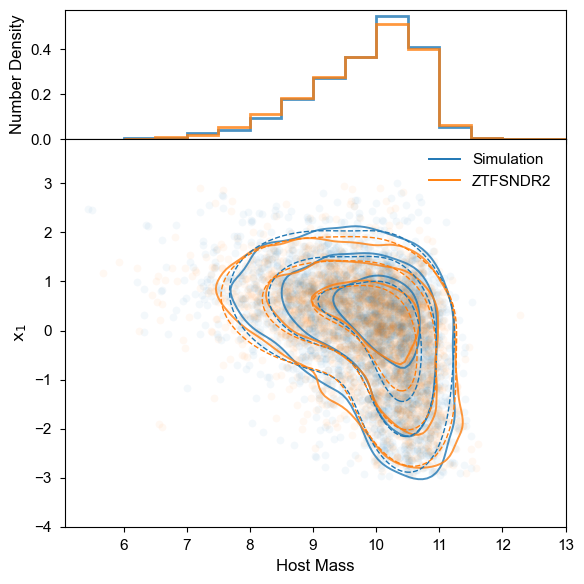

In [39]:
idx = saltpar_cuts
data_idx = (data.fitquality_flag == True) & (data.lccoverage_flag == True) & ~data.x1.isna() & ~data.mass.isna()
print(np.sum(idx))
print(np.sum(data_idx))

fig, (ax, ax2) = plt.subplots(2, 1,
                            gridspec_kw={'height_ratios': [1, 3]},   # top is 3x taller than bottom
                            figsize=(6, 6),sharex=True)
hostmass = merged.host_hostmass
x1 = merged.x1
c = merged.c

bins_x1 = np.linspace(-4,4,15)
bins_hostmass = np.linspace(6,13,15)

ax.hist(hostmass,bins=bins_hostmass,density=True,label='sim',histtype = 'step',lw = 2, color='C0',alpha=0.8)
ax.hist(data.loc[data.lccoverage_flag == 1].mass,bins=bins_hostmass,density=True,label='data',histtype = 'step',
        lw = 2, color='C1',alpha=0.8)
ax.set_ylabel('Number Density')

ax2.plot(np.array(hostmass)[idx],np.array(x1)[idx],'o',label='sim',alpha=0.05,color='C0')
ax2.plot(data[data_idx].mass,data[data_idx].x1,'o',label='ztf sn data release',alpha=0.05,color='C1')
ax2.legend()

data_plot = data[data_idx]
sim_host = np.array(hostmass)
sim_x1 = np.array(x1)

binwidth_host = bins_hostmass[1]-bins_hostmass[0]
binwidth_x1 = bins_x1[1]-bins_x1[0]

sim_count,sim_x_edges,sim_y_edges, _ = stats.binned_statistic_2d(sim_host,sim_x1,
                                             np.ones(len(sim_host)),
                                             statistic='sum',bins=[bins_hostmass,bins_x1])
data_count,data_x_edges,data_y_edges,_ = stats.binned_statistic_2d(data_plot.mass,data_plot.x1,
                                         np.ones(len(data_plot.mass)),
                                         statistic='sum',bins=[bins_hostmass,bins_x1])
sim_x = 0.5* (sim_x_edges[:-1]+sim_x_edges[1:])
sim_y = 0.5* (sim_y_edges[:-1]+sim_y_edges[1:])
data_x = 0.5* (data_x_edges[:-1]+data_x_edges[1:])
data_y = 0.5* (data_y_edges[:-1]+data_y_edges[1:])
# sim_x_plot,sim_y_plot = np.meshgrid(sim_x, sim_y)
# data_x_plot,data_y_plot = np.meshgrid(data_x, data_y)
# CS = ax2.contour(sim_x_plot.T,sim_y_plot.T,sim_count/np.sum(sim_count)/binwidth_host/binwidth_x1,alpha=0.5,levels=[0.01,0.05,0.1],colors='blue')
# CS = ax2.contour(data_x_plot.T,data_y_plot.T,data_count/np.sum(data_count)/binwidth_host/binwidth_x1,alpha=0.5,levels=[0.01,0.05,0.1],colors='red')
# proxies = [Line2D([],[],color=c) for c in ['blue','red']]
# plt.legend(proxies,['sim', 'data'])
# plt.xlabel('host mass')
# plt.ylabel('x1')
# plt.ylim((-4,4))


# ----------------------------------------------------------------------
# Settings: bin ranges (also used for KDE grid)
# ----------------------------------------------------------------------
bins_x1       = np.linspace(-4, 4, 15)
bins_hostmass = np.linspace(6, 13, 15)

x1_min, x1_max           = bins_x1[0],       bins_x1[-1]
hostmass_min, hostmass_max = bins_hostmass[0], bins_hostmass[-1]

# Resolution of KDE grid
nx = 100
ny = 100

# Mask out NaN/inf
mask_sim = np.isfinite(sim_host) & np.isfinite(sim_x1)
sim_host_clean = sim_host[mask_sim]
sim_x1_clean   = sim_x1[mask_sim]

# Data arrays
data_mass = data_plot.mass.to_numpy()
data_x1   = data_plot.x1.to_numpy()

mask_data = np.isfinite(data_mass) & np.isfinite(data_x1)
data_mass_clean = data_mass[mask_data]
data_x1_clean   = data_x1[mask_data]

# ----------------------------------------------------------------------
# Build KDEs
# ----------------------------------------------------------------------
# Sim KDE
values_sim = np.vstack([sim_host_clean, sim_x1_clean])  # shape (2, N)
kde_sim = stats.gaussian_kde(values_sim)

# Optional: tweak bandwidth (e.g., smoother by factor 1.2)
# kde_sim.set_bandwidth(bw_method=lambda *args, **kwargs: 1.2 * kde_sim.scotts_factor())

# Data KDE
values_data = np.vstack([data_mass_clean, data_x1_clean])
kde_data = stats.gaussian_kde(values_data)

# Optional: tweak bandwidth separately for data
# kde_data.set_bandwidth(bw_method=lambda *args, **kwargs: 1.0 * kde_data.scotts_factor())

# ----------------------------------------------------------------------
# Evaluate KDEs on a common grid
# ----------------------------------------------------------------------
host_grid = np.linspace(hostmass_min, hostmass_max, nx)  # x-axis
x1_grid   = np.linspace(x1_min,       x1_max,       ny)  # y-axis

H, X = np.meshgrid(host_grid, x1_grid)  # H: host mass, X: x1
positions = np.vstack([H.ravel(), X.ravel()])  # shape (2, nx*ny)

Z_sim  = kde_sim(positions).reshape(H.shape)   # PDF sim
Z_data = kde_data(positions).reshape(H.shape)  # PDF data

# ----------------------------------------------------------------------
# Choose contour levels (using percentiles so it adapts to your data)
# ----------------------------------------------------------------------
# You can tune these percentiles for how "central" the contours are
sim_levels_percentiles  = [80, 90, 97]
data_levels_percentiles = [80, 90, 97]

sim_levels  = np.percentile(Z_sim,  sim_levels_percentiles)
data_levels = np.percentile(Z_data, data_levels_percentiles)

# ----------------------------------------------------------------------
# Plot
# ----------------------------------------------------------------------

CS_sim = ax2.contour(
    host_grid, x1_grid, Z_sim,
    levels=sim_levels, colors='C0', alpha=0.8
)
CS_data = ax2.contour(
    host_grid, x1_grid, Z_data,
    levels=data_levels, colors='C1', alpha=0.8
)

# Legend using proxy artists
proxies = [Line2D([], [], color=c) for c in ['C0', 'C1']]
ax2.legend(proxies, ['Simulation', 'ZTFSNDR2'])

ax2.set_xlabel('Host Mass')
ax2.set_ylabel(r"$\mathrm{x_1}$")
ax2.set_ylim(-4, 3.9)

p,D = ks2d2s(sim_x,sim_y,data_x,data_y,extra=True)
print("KS:",p,D)

print("KLD=",stats.entropy(np.clip(data_count,1.e-8,None),np.clip(sim_count,1.e-8,None),axis=None))

gmm_sim = fit_gmm_2d(np.array(hostmass)[idx],np.array(x1)[idx])
weights, means, covs = get_gmm_pars_2d(gmm_sim)
print("weights=",weights)
print("means=",means)
print("covs=",covs)
plot_gmm_2d(bins_hostmass, bins_x1, weights, means, covs, levels=sim_levels, colors='C0',
            linestyles='--',linewidths=1)
gmm_data = fit_gmm_2d(data[data_idx].mass,data[data_idx].x1)
weights, means, covs = get_gmm_pars_2d(gmm_data)
print("weights=",weights)
print("means=",means)
print("covs=",covs)
plot_gmm_2d(bins_hostmass, bins_x1, weights, means, covs, levels=data_levels, colors='C1',
            linestyles='--',linewidths=1)

fig.tight_layout()
fig.subplots_adjust(hspace=0)
fig.savefig('paper_figs/host_x1.png', dpi=300, bbox_inches='tight')

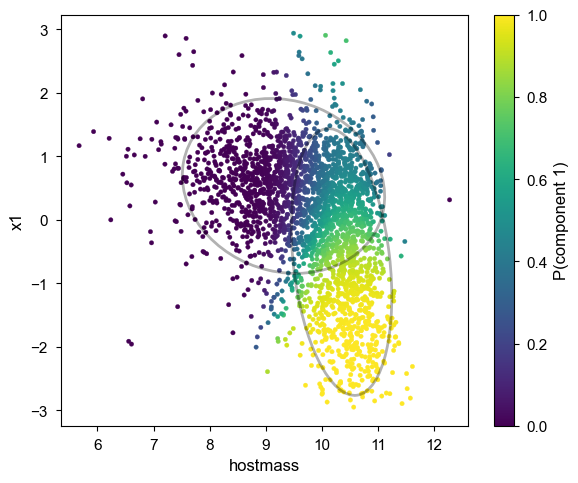

In [40]:
def plot_gmm_ellipses(ax, gmm, n_std=2):
    for w, mu, cov in zip(gmm.weights_, gmm.means_, gmm.covariances_):
        vals, vecs = np.linalg.eigh(cov)
        order = vals.argsort()[::-1]
        vals, vecs = vals[order], vecs[:, order]

        angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
        width, height = 2 * n_std * np.sqrt(vals)

        ell = Ellipse(
            xy=mu,
            width=width,
            height=height,
            angle=angle,
            alpha=0.3,
            fill=False,
            lw=2
        )
        ax.add_patch(ell)

X = np.array(data.loc[data_idx,["mass","x1"]])

resp = gmm_data.predict_proba(X)   # shape (N, K)
p1 = resp[:, 0]   # probability of component 1

plt.figure(figsize=(6, 5))
sc = plt.scatter(
    X[:, 0], X[:, 1],
    c=p1,
    s=10,
    cmap="viridis",
    vmin=0, vmax=1
)
plot_gmm_ellipses(plt.gca(), gmm_data)
plt.colorbar(sc, label="P(component 1)")
plt.xlabel("hostmass")
plt.ylabel("x1")
plt.tight_layout()
plt.show()

### Fig. 7

In [41]:
# data quality flags

# from https://github.com/ZwickyTransientFacility/ztfcosmo/blob/260e136be064708e1238719880ce18844027422e/ztfcosmo/lightcurve.py#L111
# flagout: [list of int or string]
#     flag == 0 means all good, but may not be detected:
    
#     0: no warning 
#     1: flux_err==0 Remove unphysical errors 
#     2: chi2dof>3: Remove extreme outliers 
#     4: cloudy>1: BTS cut 
#     8: infobits>0: BTS cut 
#     16: mag_lim<19.3: Cut applied in Dhawan 2021 
#     32: seeing>3: Cut applied in Dhawan 2021 
#     64: fieldid>879: Recommended IPAC cut 
#     128: moonilf>0.5: Recommended IPAC cut 
#     256: has_baseline>1: Has a valid baseline correction 
#     512: airmass>2: Recommended IPAC cut 
#     1024: flux/flux_err>=5: Nominal detection

In [42]:
# ztf sndr2 flags
# sn_type SNIa classification 
# sub_type sub classification if any. 
# lccoverage_flag passes the good sampling cut (bool,Table1) 
# fitquality_flag passes all other Basic cuts (bool,Table1)

In [43]:
def filter_flags(lc_flag, flags_to_exclude=[], flags_to_include=[]):
    pass_filter = True
    if len(flags_to_include)>0:
        pass_filter &= np.all([lc_flag & flag != 0 for flag in flags_to_include])
    if len(flags_to_exclude)>0:
        pass_filter &= np.all([lc_flag & flag == 0 for flag in flags_to_exclude])
    return pass_filter

In [44]:
#calculate this first
lcdata["lc.pass_flag_filter"] = lcdata["lc.flag"].apply(filter_flags,flags_to_exclude=[1,2,4,8],flags_to_include=[])
lcdata["lc.pass_flag_filter_all"] = lcdata["lc.flag"].apply(filter_flags,flags_to_exclude=[1,2,4,8,16,32,64,128,256,512],flags_to_include=[])
lcdata["lc.pass_detection"] = lcdata["lc.flag"].apply(filter_flags,flags_to_exclude=[],flags_to_include=[1024])

lcdata['lc.snr'] = lcdata['lc.flux']/lcdata['lc.flux_err']
lcdata["lc.pass_snr_detection"] = lcdata["lc.snr"] > 5

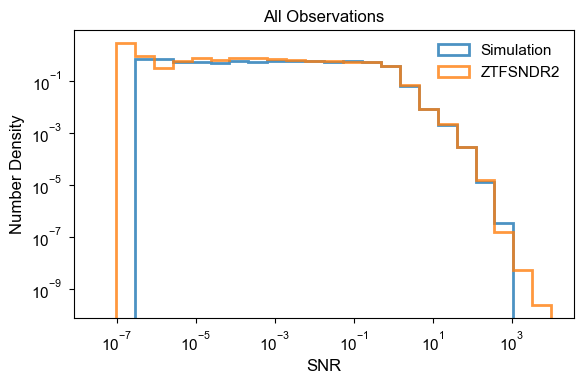

In [45]:
lc_to_plot = lightcurves.loc[lightcurves_after_spec_selection.index]
lc_to_plot = lc_to_plot.query("lc.infobits == 0").dropna(subset="lc") 
lcdata_plot = lcdata.query("lc.pass_flag_filter==True").dropna(subset="lc")

t_min_obslog,t_max_obslog = 58288.171875, 59273.5546875
lcdata_plot = lcdata_plot.query(f"lc.mjd>= {t_min_obslog} & lc.mjd <= {t_max_obslog}").dropna(subset="lc")

# lc_to_plot["lc.phase"] =  (lc_to_plot["lc.mjd"] - lc_to_plot["t0"])/(1.+lc_to_plot["z"])
# lcdata_plot["lc.phase"] = (lcdata_plot["lc.mjd"] - lcdata_plot["t0"])/(1.+lcdata_plot["redshift"])

# lc_to_plot = lc_to_plot.query("lc.phase < 100 & lc.phase > -30").dropna(subset="lc")
# lcdata_plot = lcdata_plot.query("lc.phase < 100 & lc.phase > -30").dropna(subset="lc")

bins = np.logspace(-7.5,4,25)

ax = plot_snr_distr([lc_to_plot, lcdata_plot],bins=bins,density=True,
               histtype='step',labels=['Simulation','ZTFSNDR2'],lw=2,alpha=0.8)
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel('SNR')
ax.set_ylabel(r"Number Density")
ax.set_title('All Observations')
plt.tight_layout()
plt.savefig('paper_figs/snr_allobs.png', dpi=300, bbox_inches='tight')

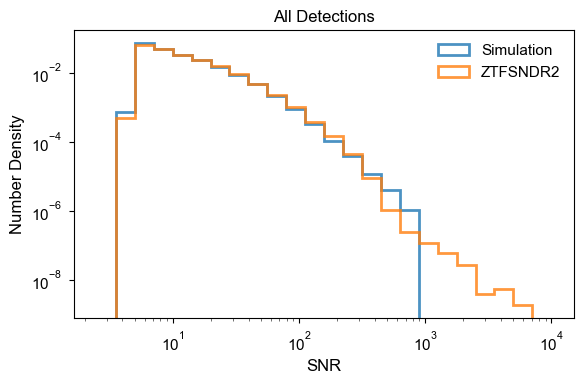

In [46]:
lc_to_plot = lightcurves_after_detection.loc[lightcurves_after_spec_selection.index]
lc_to_plot = lc_to_plot.query("lc.infobits == 0").dropna(subset="lc") 
lcdata_plot = lcdata.query("lc.pass_flag_filter == True & lc.pass_detection == True & lc.pass_snr_detection == True").dropna(subset="lc")

t_min_obslog,t_max_obslog = 58288.171875, 59273.5546875
lcdata_plot = lcdata_plot.query(f"lc.mjd>= {t_min_obslog} & lc.mjd <= {t_max_obslog}").dropna(subset="lc")

lc_to_plot["lc.phase"] =  (lc_to_plot["lc.mjd"] - lc_to_plot["t0"])/(1.+lc_to_plot["z"])
lcdata_plot["lc.phase"] = (lcdata_plot["lc.mjd"] - lcdata_plot["t0"])/(1.+lcdata_plot["redshift"])

lc_to_plot = lc_to_plot.query("lc.phase < 100 & lc.phase > -30").dropna(subset="lc")
lcdata_plot = lcdata_plot.query("lc.phase < 100 & lc.phase > -30").dropna(subset="lc")

bins = np.logspace(0.4,4,25)

ax = plot_snr_distr([lc_to_plot, lcdata_plot],bins=bins,density=True,
               histtype='step',labels=['Simulation','ZTFSNDR2'],lw=2,alpha=0.8)
ax.set_yscale('log')
ax.yaxis.set_major_locator(LogLocator(base=10,numticks=5))
ax.minorticks_off()
ax.set_xscale('log')
ax.set_xlabel('SNR')
ax.set_ylabel(r"Number Density")
ax.set_title('All Detections')
plt.tight_layout()
plt.savefig('paper_figs/snr_alldetection.png', dpi=300, bbox_inches='tight')

### Fig. 8

In [47]:
lc_to_plot = lightcurves_after_detection.loc[lightcurves_after_spec_selection.index]
lc_to_plot = lc_to_plot.query("lc.infobits == 0").dropna(subset="lc") 
lcdata_plot = lcdata.query("lc.pass_flag_filter == True & lc.pass_snr_detection == True").dropna(subset="lc")

# ---- Convert flux to nJy for data ----
lcdata_plot["lc.flux"], lcdata_plot["lc.flux_err"] = convert_flux_to_njy(
    lcdata_plot['lc.flux'], lcdata_plot['lc.flux_err'], zp=30.
)

lc_to_plot["lc.phase"] =  (lc_to_plot["lc.mjd"] - lc_to_plot["t0"])/(1.+lc_to_plot["z"])
lcdata_plot["lc.phase"] = (lcdata_plot["lc.mjd"] - lcdata_plot["t0"])/(1.+lcdata_plot["redshift"])

lc_to_plot = lc_to_plot.query("lc.phase < 100 & lc.phase > -20").dropna(subset="lc")
lcdata_plot = lcdata_plot.query("lc.phase < 100 & lc.phase > -20").dropna(subset="lc")

maxfluxcut = mag2flux(12.5)
print(f"Remove flux >= {maxfluxcut:.2e}")
lc_to_plot = lc_to_plot.query(f"lc.flux < {maxfluxcut}")
lcdata_plot = lcdata_plot.query(f"lc.flux < {maxfluxcut}")

Remove flux >= 3.63e+07


Nsim: 329515.0
Ndata 293971.0
[1.00000000e-05 3.16227766e-05 1.00000000e-04 3.16227766e-04
 1.00000000e-03 3.16227766e-03 1.00000000e-02 3.16227766e-02]
[-5.  -4.5 -4.  -3.5 -3.  -2.5 -2.  -1.5]


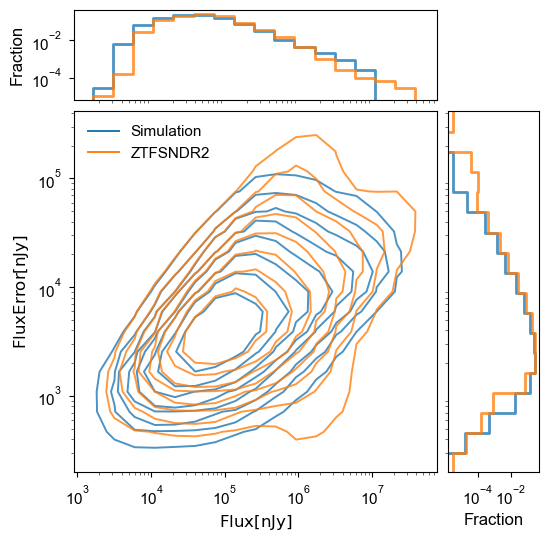

In [48]:
plot_logflux_vs_logfluxerr_corner(lc_to_plot, lcdata_plot, smooth_sigma=1,
                                  labels=['Simulation','ZTFSNDR2'],fraction=True)
plt.savefig('paper_figs/logflux_contour.png', dpi=300, bbox_inches='tight')

Nsim: 4260.0
Ndata 3447.0
[0.00031623 0.001      0.00316228 0.01       0.03162278]
[-3.5 -3.  -2.5 -2.  -1.5]


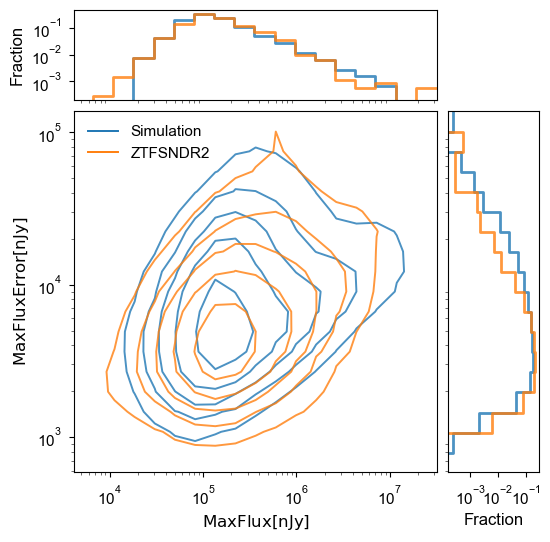

In [49]:
lcdata_plot = lcdata_plot.query("lc.pass_flag_filter_all == True").dropna(subset=["lc"])
lc_to_plot = lc_to_plot.query("lc.phase < 40 & lc.phase > -10").dropna(subset="lc")
lcdata_plot = lcdata_plot.query("lc.phase < 40 & lc.phase > -10").dropna(subset="lc")

plot_logmaxflux_vs_logmaxfluxerr_corner(lc_to_plot,lcdata_plot,smooth_sigma=1,
                                        labels=['Simulation','ZTFSNDR2'],fraction=True)
plt.savefig('paper_figs/logmaxflux_contour.png', dpi=300, bbox_inches='tight')

### Fig. 9

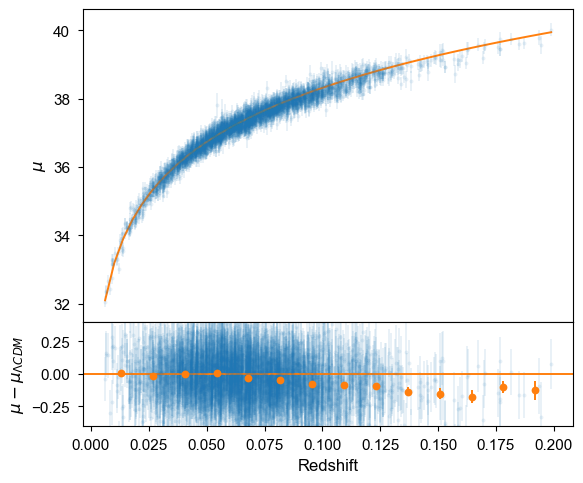

In [50]:
# make HD

x1_hd = result_df.loc[saltpar_cuts,"x1"]
c_hd = result_df.loc[saltpar_cuts,"c"]
x0_hd = result_df.loc[saltpar_cuts,"x0"]
z_hd = result_df.loc[saltpar_cuts,"z"]

x1_err = result_df.loc[saltpar_cuts,"x1_err"]
c_err = result_df.loc[saltpar_cuts,"c_err"]
x0_err = result_df.loc[saltpar_cuts,"x0_err"]

mb_hd = -2.5*np.log10(x0_hd) + 10.635
mb_err = 2.5/np.log(10) * (x0_err/x0_hd)

alpha = ALPHA
beta = BETA
Mb = MAGABS
mu_hd = mb_hd + alpha*x1_hd - beta*c_hd - Mb
mu_err = np.sqrt(mb_err**2 + alpha**2*x1_err**2 + beta**2*c_err**2 + SIGMA_MAGABS**2)

fig, (ax1, ax2) = plt.subplots(2, 1,
                            gridspec_kw={'height_ratios': [3, 1]},   # top is 3x taller than bottom
                            figsize=(6, 5),sharex=True)

ax1.errorbar(z_hd, mu_hd, yerr=mu_err,fmt='.',alpha=0.1)

z_cosmo = np.linspace(z_hd.min(),z_hd.max(),50)
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
mu_cosmo = cosmo.distmod(z_cosmo)
ax1.plot(z_cosmo, mu_cosmo)

ax1.set_ylabel(r'$\mu$')

mures = mu_hd - cosmo.distmod(z_hd).value

# ax2 = plt.subplot(3,1,2, sharex=ax1)
ax2.errorbar(z_hd, mures, yerr=mu_err, fmt='.',alpha=0.1)
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
ax2.axhline(y=0,color=colors[1])
ax2.set_ylim((-0.4,0.4))
ax2.set_ylabel(r'$\mu - \mu_{\Lambda CDM}$')
ax2.set_xlabel('Redshift')

bins= np.linspace(z_hd.min(),z_hd.max(),15)
mures_mean, bin_edges, _ = stats.binned_statistic(
    z_hd, mures, statistic='mean', bins= bins
)

mures_std, bin_edges, _ = stats.binned_statistic(
    z_hd, mures, statistic='std', bins= bins
)

mures_count, bin_edges, _ = stats.binned_statistic(
    z_hd, mures, statistic='count', bins= bins
) 

mures_err = mures_std / np.sqrt(mures_count)

bin_mean = (bin_edges[:-1] + bin_edges[1:])*0.5
ax2.errorbar(bin_mean, mures_mean, yerr = mures_err,fmt='o')

# ax3 = plt.subplot(3,1,3, sharex=ax1)
# ax3.errorbar(bin_mean, mures_mean, yerr = mures_err,fmt='o')
# ax3.axhline(y=0,color=colors[1])
# ax3.set_ylim((-0.2,0.2))
fig.tight_layout()
fig.subplots_adjust(hspace=0)

plt.savefig('paper_figs/HD.png', dpi=300, bbox_inches='tight')

In [51]:
print(f"mures RMS: {np.sqrt(np.mean(mures**2))}")
print(f"mures STD: {np.std(mures)}")

mures RMS: 0.1808674085813488
mures STD: 0.177294030793559


In [52]:
def make_bined_mures_par_plot(cut):
    nbins = 15
    bins_hostmass = np.linspace(7,12,nbins)
    bins_x1 = np.linspace(-3,3,nbins)
    bins_c = np.linspace(-0.2,0.8,nbins)
    bins_arr = [bins_hostmass,bins_x1,bins_c]
    
    fig = plt.figure(figsize=(6,5))
    i=0
    label_map = {'host_hostmass': 'Host Mass',
                 'x1': r'$\mathrm{x_1}$',
                 'c': 'c'}
    for bins, par in zip(bins_arr,['host_hostmass','x1','c']):
        i = i+1 
        fig.add_subplot(3,1,i)
        x_plot = merged[cut][par]
        x_mean, bin_edges, _ = stats.binned_statistic(
            x_plot, mures[cut], statistic='mean', bins= bins
        )
        
        x_std, bin_edges, _ = stats.binned_statistic(
            x_plot, mures[cut], statistic='std', bins= bins
        )
        
        x_count, bin_edges, _ = stats.binned_statistic(
            x_plot, mures[cut], statistic='count', bins= bins
        ) 
    
        x_err = x_std / np.sqrt(x_count)
        
        bin_mean = (bin_edges[:-1] + bin_edges[1:])*0.5
        plt.errorbar(bin_mean, x_mean, yerr =x_err,fmt='o')
    
        plt.axhline(y=0,ls=':',c='gray')
        plt.xlabel(label_map[par])
        plt.ylabel(r'$\mu - \mu_{\Lambda CDM}$')
    fig.tight_layout()

### Fig. 10

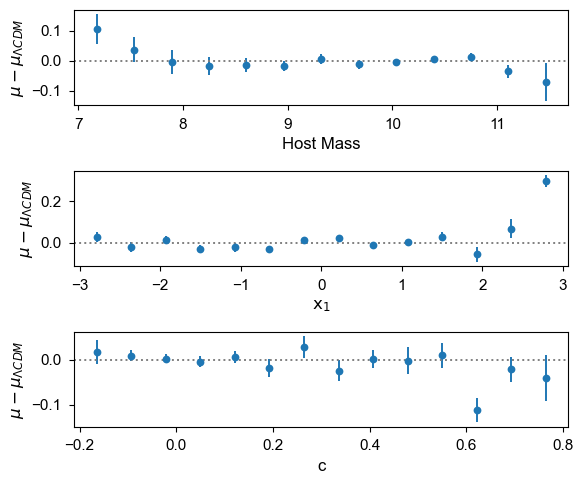

In [53]:
zcut = saltpars["z"]<0.06
allcut = saltpar_cuts & zcut

make_bined_mures_par_plot(allcut)

plt.savefig('paper_figs/mures_vs_par.png', dpi=300, bbox_inches='tight')

### Table 3

In [54]:
def calculate_median_cadence(mjd):
    mjd = np.sort(mjd)
    mjd_diff = np.diff(mjd)
    return np.median(mjd_diff)

In [55]:
#caculate nobs, ndetections

for f in "gri":
    lc_to_show = lightcurves_after_spec_selection.dropna(subset="lc")
    lc_to_show = lc_to_show.query("lc.infobits == 0").dropna(subset="lc")    
    data_to_show = lcdata.query("lc.pass_flag_filter == True").dropna(subset="lc")
    data_to_show["lc.detection_flag"] = data_to_show["lc.pass_snr_detection"]
    
    t_min_obslog,t_max_obslog = 58288.171875, 59273.5546875
    data_to_show = data_to_show.query(f"lc.mjd>= {t_min_obslog} & lc.mjd <= {t_max_obslog}").dropna(subset="lc")

    lc_to_show["lc.phase"] =  (lc_to_show["lc.mjd"] - lc_to_show["t0"])/(1.+lc_to_show["z"])
    data_to_show["lc.phase"] = (data_to_show["lc.mjd"] - data_to_show["t0"])/(1.+data_to_show["redshift"])
    
    lc_to_show["lc"] = lc_to_show["lc"].nest[lc_to_show["lc.filter"] == f]
    data_to_show["lc"] = data_to_show["lc"].nest[data_to_show["lc.filter"] == "ztf"+f]

    nobs_sim = lc_to_show['lc.mjd'].count()
    nobs_data = data_to_show['lc.mjd'].count()

    ndet_sim = lc_to_show.query("lc.detection_flag == True").dropna(subset="lc")['lc.mjd'].count()
    ndet_data = data_to_show.query("lc.detection_flag == True").dropna(subset="lc")['lc.mjd'].count()
 
    ndet_sim_window = lc_to_show.query("lc.detection_flag == True & lc.phase < 50 & lc.phase > -20").dropna(subset="lc")['lc.mjd'].count()
    ndet_data_window = data_to_show.query("lc.detection_flag == True & lc.phase < 50 & lc.phase > -20").dropna(subset="lc")['lc.mjd'].count()
    
    avg_nobs_sim = nobs_sim/len(lc_to_show)
    avg_nobs_data = nobs_data/len(data_to_show)
    avg_ndet_sim = ndet_sim/len(lc_to_show)
    avg_ndet_data = ndet_data/len(data_to_show)
    avg_ndet_sim_win = ndet_sim_window/len(lc_to_show)
    avg_ndet_data_win = ndet_data_window/len(data_to_show)
    
    avg_cadence_sim = lc_to_show.reduce(calculate_median_cadence,"lc.mjd")
    avg_cadence_data = data_to_show.reduce(calculate_median_cadence,"lc.mjd")
    
    avg_cadence_sim_det = lc_to_show.query("lc.detection_flag==True").reduce(calculate_median_cadence,"lc.mjd")
    avg_cadence_data_det = data_to_show.query("lc.detection_flag==True").reduce(calculate_median_cadence,"lc.mjd")

    print(f"filter = {f}")
    print("     |Nevent|N_obs    | N_det | N_det,win  |  <N_obs>      | <N_det>   | <N_det,win> | Median Cadence  | Median Detection Cadence   ")

    print(f" sim |{len(lc_to_show)} | {nobs_sim} | {ndet_sim}  | {ndet_sim_window} | {avg_nobs_sim:.2f}  | {avg_ndet_sim:.2f} | {avg_ndet_sim_win:.2f} |{avg_cadence_sim.median()[0]:.2f} | {avg_cadence_sim_det.median()[0]:.2f}")
    print(f" data|{len(data_to_show)} | {nobs_data} | {ndet_data}  | {ndet_data_window} | {avg_nobs_data:.2f} | {avg_ndet_data:.2f} | {avg_ndet_data_win:.2f} |{avg_cadence_data.median()[0]:.2f} |{avg_cadence_data_det.median()[0]:.2f}")


filter = g
     |Nevent|N_obs    | N_det | N_det,win  |  <N_obs>      | <N_det>   | <N_det,win> | Median Cadence  | Median Detection Cadence   
 sim |4313 | 1588686 | 115106  | 94609 | 368.35  | 26.69 | 21.94 |1.03 | 2.00
 data|3592 | 1267460 | 102326  | 84162 | 352.86 | 28.49 | 23.43 |1.03 |1.99
filter = r
     |Nevent|N_obs    | N_det | N_det,win  |  <N_obs>      | <N_det>   | <N_det,win> | Median Cadence  | Median Detection Cadence   
 sim |4313 | 2159803 | 213619  | 152888 | 500.77  | 49.53 | 35.45 |0.95 | 1.04
 data|3592 | 1649064 | 162671  | 132487 | 459.09 | 45.29 | 36.88 |0.96 |1.08
filter = i
     |Nevent|N_obs    | N_det | N_det,win  |  <N_obs>      | <N_det>   | <N_det,win> | Median Cadence  | Median Detection Cadence   
 sim |4313 | 306993 | 26289  | 19800 | 71.18  | 6.10 | 4.59 |3.09 | 4.00
 data|3592 | 224896 | 17786  | 15558 | 62.61 | 4.95 | 4.33 |3.99 |4.57
